Importing libraries

In [1]:
!pip install pandas
import pandas as pd
import os 
print(os.getcwd()) # directory address
df=pd.read_excel("../Dataset/Data_set.xlsx")
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())


C:\Users\HP\OneDrive\Desktop\Project\Notebooks

Columns:
Index(['Peptide_ID', 'Title', 'Sequence', 'Source_Organism', 'Activity',
       'Gram_Nature'],
      dtype='object')

First 5 rows:
  Peptide_ID                       Title    Sequence  \
0    CAMPSQ7                     Sesquin  KTCENLADTY   
1   CAMPSQ17      Antifungal lectin PVAP  SNDIYFNFQR   
2  CAMPSQ519                      Gymnin  KTCENLADDY   
3  CAMPSQ593  Antimicrobial ribonuclease  DNGEAGRAAR   
4  CAMPSQ652                    Coccinin  KQTENLADTY   

                           Source_Organism Activity       Gram_Nature  
0  Vigna unguiculata subsp. sesquipedalis       AMP  Gram+ve, Gram-ve  
1                      Phaseolus vulgaris       AMP               NaN  
2                   Gymnocladus chinensis       AMP               NaN  
3                      Lentinus sajor-caju      AMP  Gram+ve, Gram-ve  
4                     Phaseolus coccineus       AMP               NaN  


Data Preparation & Validation Phase
Step1- Inspection of sheet names

In [2]:
import pandas as pd #structured data manipulation
file_path= "../Dataset/Data_set.xlsx"
xls=pd.ExcelFile(file_path) #ExcelFile allows checking metadata
print("Sheet names:",xls.sheet_names) #print available sheet names




Sheet names: ['AMP', 'non-AMP']


Step 2 — Load Both Sheets Separately

In [3]:
amp_df=pd.read_excel(file_path,sheet_name="AMP")#laoad amp sheet
nonamp_df=pd.read_excel(file_path,sheet_name="non-AMP")#load non amp sheet
print("AMP_shape:",amp_df.shape)# Check dimensions
print("nonAMP_shape:",nonamp_df.shape)# Check dimensions (rows,columns)

AMP_shape: (2638, 6)
nonAMP_shape: (3700, 5)


Step 3 — Create Explicit Binary Labels

In [4]:
amp_df["label"]=1 #positive class
nonamp_df["label"]=0 #negative class

Step 4 — Combine Datasets- Classifier expects a single feature matrix and label vector.

In [5]:
# Concatenate both datasets vertically
df = pd.concat([amp_df, nonamp_df], ignore_index=True)

# Check combined dataset
print("Combined shape:", df.shape)

# Check class distribution
print("\nLabel distribution:")
print(df["label"].value_counts())

Combined shape: (6338, 7)

Label distribution:
label
0    3700
1    2638
Name: count, dtype: int64


Step 5 — Check Missing Values

In [6]:
print('Missing values:')
print(df.isnull().sum())


Missing values:
Peptide_ID            0
Title                 0
Sequence              0
Source_Organism       0
Activity              0
Gram_Nature        4435
label                 0
dtype: int64


Step 6 — Check Duplicate Sequences

Duplicate sequences can:
Inflate accuracy
Cause data leakage
Reduce generalization

In [7]:
duplicate_count=df["Sequence"].duplicated().sum()
print("duplicate sequences:", duplicate_count)

duplicate sequences: 0


In [8]:
print("amp columns:")
print(amp_df.columns.tolist())
print("non-amp columns:")
print(nonamp_df.columns.tolist())

amp columns:
['Peptide_ID', 'Title', 'Sequence', 'Source_Organism', 'Activity', 'Gram_Nature', 'label']
non-amp columns:
['Peptide_ID', 'Title', 'Sequence', 'Source_Organism', 'Activity', 'label']


As there is a column mismatch in the amp and non amp dataframe so, we extract only essential features, such as only sequence and labels.
As combining whole data in future can give nan values due to overlapping and imbalance in data, because non amp dataframe lacks 
gram property.

In [9]:
# print(type(amp_df))
# amp_df=amp_df[['Sequence']]
# nonamp_df=nonamp_df[['Sequence']] # only sequence column
# amp_df['label']=1 # also adding labels
# nonamp_df['label']=0
# #combining
# df=pd.concat([amp_df,nonamp_df],ignore_index=True)
# #verify
# print('Final shape:',df.shape)
# print(df['label'].value_counts())
# print(df.isnull().sum())

we are restarting the kernel and starting fresh and rewriting the pipeline again as we converted our data frame earlier to series
and after getting insights from data that we needed some different extracts from the data due to columns mismatch, that is we needed
only label and sequence for classification, we could have gone with everything but the non amp sheet lacked the gram natur column so
we decided to go with only essential part that is what we mainly need but during early process we already created the data frames to series
so even after rewriting the code the code dataframe cannot be created from series type.

In [10]:
import pandas as pd
# df=pd.read_excel("../Dataset/Data_set.xlsx")
# df
file_path="../Dataset/Data_set.xlsx"
amp_df=pd.read_excel(file_path,sheet_name="AMP")
nonamp_df=pd.read_excel(file_path,sheet_name="non-AMP") #reading the file
print(type(amp_df))
print(type(nonamp_df)) # type frame or series
print("AMP Shape:",amp_df.shape)
print("non-AMP Shape:",nonamp_df.shape) # shapes
# checking columns to avoid keyerror
print("AMP columns:",amp_df.columns)
print("non-AMP columns:",nonamp_df.columns)
# now only keeping the sequence columns as classifier only needs sequence
amp_df=amp_df[["Sequence"]]
nonamp_df=nonamp_df[["Sequence"]]
#  now adding label for classification
amp_df["label"]=1
nonamp_df["label"]=0
# combining datasets
df=pd.concat([amp_df,nonamp_df],ignore_index=True)
print('final shape:',df.shape)
print(df["label"].value_counts())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
AMP Shape: (2638, 6)
non-AMP Shape: (3700, 5)
AMP columns: Index(['Peptide_ID', 'Title', 'Sequence', 'Source_Organism', 'Activity',
       'Gram_Nature'],
      dtype='object')
non-AMP columns: Index(['Peptide_ID', 'Title', 'Sequence', 'Source_Organism', 'Activity'], dtype='object')
final shape: (6338, 2)
label
0    3700
1    2638
Name: count, dtype: int64
Sequence    0
label       0
dtype: int64


EDA

Finding length of sequences and storing it into new column

In [11]:
# create a new column called 'length'
# for each sequence in the Sequence column
# apply the Python len() function

df['length']=df['Sequence'].apply(len)
#  to check if column is created or not 
print(df.head())
print(df['length'].describe())

     Sequence  label  length
0  KTCENLADTY      1      10
1  SNDIYFNFQR      1      10
2  KTCENLADDY      1      10
3  DNGEAGRAAR      1      10
4  KQTENLADTY      1      10
count    6338.000000
mean       47.992742
std        24.271203
min        10.000000
25%        26.000000
50%        45.000000
75%        70.000000
max        90.000000
Name: length, dtype: float64


Comparing AMP vs non-AMP in length distribution if difference appears or not

In [12]:
amp_length=df[df['label']==1]['length']
nonamp_length=df[df['label']==0]['length']
print("length distribution:",amp_length.describe())
print("length distribution:",nonamp_length.describe())



length distribution: count    2638.000000
mean       33.589462
std        17.041923
min        10.000000
25%        20.000000
50%        30.000000
75%        43.000000
max        90.000000
Name: length, dtype: float64
length distribution: count    3700.000000
mean       58.261892
std        23.425061
min        10.000000
25%        39.000000
50%        64.000000
75%        78.000000
max        90.000000
Name: length, dtype: float64


Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

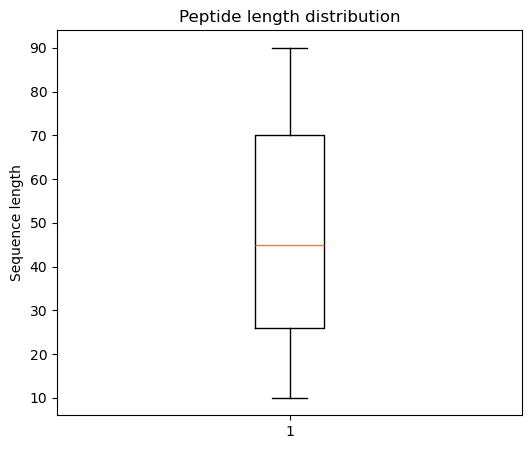

In [13]:
import matplotlib.pyplot as plt
# amplength=df[df['label']==1],['length']
# nonamplength=df[df['label']==0,['length']
plt.figure(figsize=(6,5))
plt.boxplot(df['length'])
plt.title('Peptide length distribution')
plt.ylabel('Sequence length')
plt.show
           

<function matplotlib.pyplot.show(close=None, block=None)>

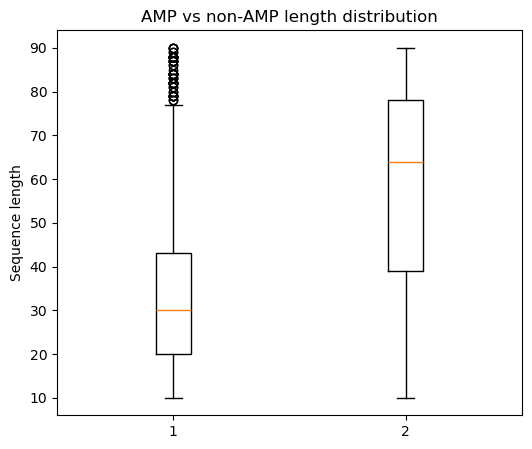

In [14]:
plt.figure(figsize=(6,5))
plt.boxplot([amp_length, nonamp_length],label=[1,0])
plt.title('AMP vs non-AMP length distribution')
plt.ylabel('Sequence length')
plt.show
           

We will use AAC as features, as machine learning does not learn about strings but learn about numerical features, we calculate 20
dimension numeric vector, this will turn every sequence into the frequency of amino acid occurrence

In [15]:
amino_acids="ARNDCQEGHILKMFPSTWYV"
def compute_aac(Sequence):
    length=len(Sequence)
    aac_values=[]
    for aa in amino_acids:
        count=Sequence.count(aa)
        freq=count/length
        aac_values.append(freq)
    return aac_values
aac_features=df['Sequence'].apply(compute_aac)
aac_df=pd.DataFrame(aac_features.tolist(), columns=list(amino_acids))
aac_df['label']=df['label']
print(aac_df.shape)
print(aac_df.head())


(6338, 21)
     A    R    N    D    C    Q    E    G    H    I  ...    K    M    F    P  \
0  0.1  0.0  0.1  0.1  0.1  0.0  0.1  0.0  0.0  0.0  ...  0.1  0.0  0.0  0.0   
1  0.0  0.1  0.2  0.1  0.0  0.1  0.0  0.0  0.0  0.1  ...  0.0  0.0  0.2  0.0   
2  0.1  0.0  0.1  0.2  0.1  0.0  0.1  0.0  0.0  0.0  ...  0.1  0.0  0.0  0.0   
3  0.3  0.2  0.1  0.1  0.0  0.0  0.1  0.2  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4  0.1  0.0  0.1  0.1  0.0  0.1  0.1  0.0  0.0  0.0  ...  0.1  0.0  0.0  0.0   

     S    T    W    Y    V  label  
0  0.0  0.2  0.0  0.1  0.0      1  
1  0.1  0.0  0.0  0.1  0.0      1  
2  0.0  0.1  0.0  0.1  0.0      1  
3  0.0  0.0  0.0  0.0  0.0      1  
4  0.0  0.2  0.0  0.1  0.0      1  

[5 rows x 21 columns]


We calculated AAC for our sequence data. Now, we will calculate the mean of AAC of our AMP and nonAMP sequences and will compare the 
Mean of AMP and nonAMP, this will tell us which residue is present in high frequency among both classes.

In [18]:
amp_data=aac_df[aac_df['label']==1]# select rows where label = 1 (AMP peptides)
nonamp_data=aac_df[aac_df['label']==0]# select rows where label = 0 (nonAMP peptides)
amp_features=amp_data.drop('label',axis=1) # drop label column so only AAC features remain
nonamp_features=nonamp_data.drop('label',axis=1)
amp_mean=amp_features.mean() #computing mean
nonamp_mean=nonamp_features.mean()


        AMP   non-AMP
A  0.075356  0.073749
R  0.058152  0.057947
N  0.035413  0.036937
D  0.024010  0.047693
C  0.064714  0.046446
Q  0.025400  0.033584
E  0.025604  0.051506
G  0.109007  0.081239
H  0.021577  0.020089
I  0.065670  0.053308
L  0.099412  0.089919
K  0.103513  0.062088
M  0.012362  0.032238
F  0.043316  0.044875
P  0.044259  0.049068
S  0.057319  0.067708
T  0.038649  0.047453
W  0.016288  0.012942
Y  0.022830  0.028960
V  0.057150  0.062252


<Axes: >

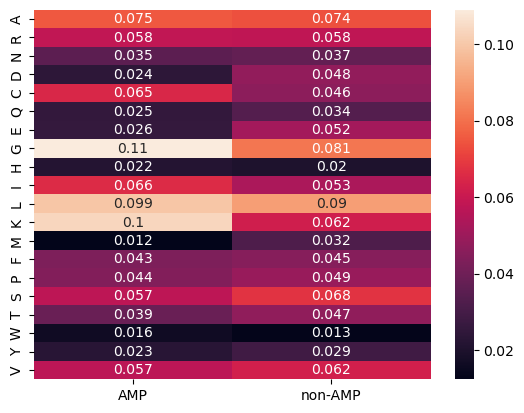

In [19]:
import seaborn as sns
comparison_df=pd.DataFrame({'AMP':amp_mean,'non-AMP':nonamp_mean}) #checking comparison of AAC mean
print(comparison_df)
sns.heatmap(comparison_df,annot=True)

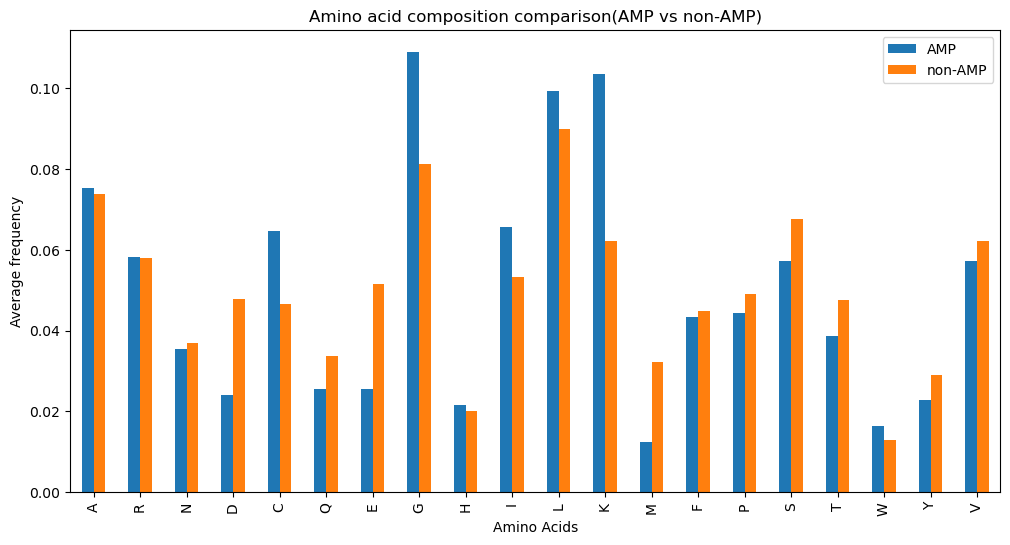

In [20]:
comparison_df.plot(kind='bar',figsize=(12,6))
plt.title('Amino acid composition comparison(AMP vs non-AMP)')
plt.xlabel('Amino Acids')
plt.ylabel('Average frequency')
# plt.xticks(rotation=0)
plt.show()

Now, charge is a very essential feature of any peptide sequence, because biologically we know to target the negatively charged
cell membrane; generally, peptide sequences with a higher charge, that is, positively charged, are favoured. So we will
calculate the net charge, which will now help the classifier, along with AAC, to separate classes initially. Using AAC, mean comparison
and plotting, we found acids with a key role here.

In [21]:
positive_charge=aac_df['K']+aac_df['R'] # contribution from positively charged amino acids
negative_charge=aac_df['D']+aac_df['E'] # contribution from negatively charged amino acids
aac_df['net_charge']=positive_charge-negative_charge # calculating the net charge
print(aac_df[['K','R','D','E','net_charge']].head())

     K    R    D    E  net_charge
0  0.1  0.0  0.1  0.1        -0.1
1  0.0  0.1  0.1  0.0         0.0
2  0.1  0.0  0.2  0.1        -0.2
3  0.0  0.2  0.1  0.1         0.0
4  0.1  0.0  0.1  0.1        -0.1


Calculating the mean of net charge using label

In [22]:
aac_df.groupby('label')['net_charge'].mean()

label
0    0.020835
1    0.112052
Name: net_charge, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

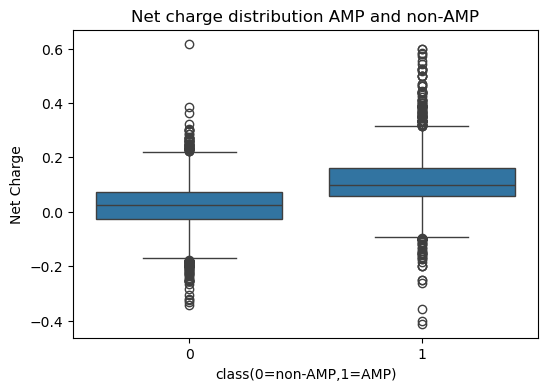

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(x='label',y='net_charge',data=aac_df)
plt.title('Net charge distribution AMP and non-AMP')
plt.xlabel('class(0=non-AMP,1=AMP)')
plt.ylabel('Net Charge')
plt.show

In [24]:
aac_df['length']=df['Sequence'].apply(len)
print(aac_df[['length','net_charge']])


      length  net_charge
0         10   -0.100000
1         10    0.000000
2         10   -0.200000
3         10    0.000000
4         10   -0.100000
...      ...         ...
6333      90    0.000000
6334      90   -0.022222
6335      90   -0.022222
6336      90   -0.033333
6337      90   -0.022222

[6338 rows x 2 columns]


In [25]:
aac_df.shape

(6338, 23)

Let us head towards the Model building part, we have features like AAC, Net charge, Sequence length

In [26]:
# Separate features and labels
X= aac_df.drop('label',axis=1) # features
Y= aac_df['label'] #target column
# checking shape
print('Feature matrix shape:', X.shape)
print('Label vector shape:', Y.shape)

Feature matrix shape: (6338, 22)
Label vector shape: (6338,)


After separating label and feature, splitting the data into test and training sets is required. We will use an 80/20 split

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=42)
print('Training set:',X_train.shape)
print('Test set:',X_test.shape)

Training set: (5070, 22)
Test set: (1268, 22)


Training XGBoost Classifier

In [35]:
from xgboost import XGBClassifier
Classifier=XGBClassifier()
Classifier
model=XGBClassifier(eval_metric='logloss')
Classifier.fit(X_train,Y_train)
# prediction stage
Y_pred= Classifier.predict(X_test)
# checking model performance
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(Y_test,Y_pred)
print('Classifier accuracy:',accuracy)

Classifier accuracy: 0.9100946372239748


only accuracy is not sufficient, let us check confusion matrix to see how model is making mistakes

Confusion matrix:
 [[674  52]
 [ 62 480]]


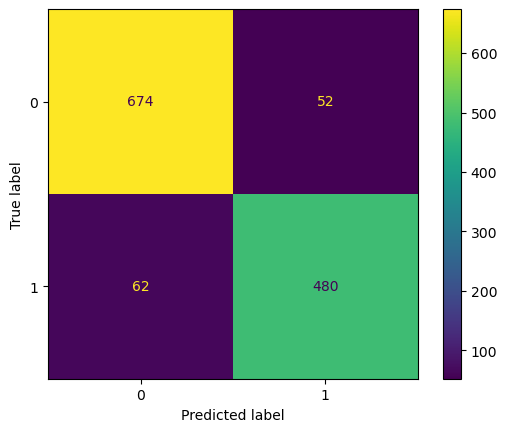

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(Y_test,Y_pred)
print('Confusion matrix:\n',cm)
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)
plt.savefig('confusion_matrix.jpeg')
plt.show()


Now we will check Precision, recall and F1

In [30]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       726
           1       0.90      0.89      0.89       542

    accuracy                           0.91      1268
   macro avg       0.91      0.91      0.91      1268
weighted avg       0.91      0.91      0.91      1268



In [36]:
import pickle
pickle.dump(Classifier,open('Classifier.pkl','wb'))

In [50]:
model=pickle.load(open('Classifier.pkl','rb'))
model.predict(X_test)
# print(model.n_features_in_)
# print(model.feature_names_in_)
                  

array([0, 1, 0, ..., 1, 0, 1])